# Тема 2. Визуальный анализ данных

## Занятие 2 (теория)

Визуализация — это не просто «красивые картинки для отчётов». В ML она используется на каждом этапе работы:

- **Знакомство с данными.** Прежде чем строить модели, нужно понять, что вообще перед нами: какие распределения, есть ли выбросы, есть ли очевидные паттерны.
- **Отбор признаков.** Графики помогают увидеть, какие переменные связаны с целевой, а какие — нет.
- **Интерпретация модели.** Результаты и ошибки модели гораздо проще осмыслить визуально.

Невероятно, сколько всего можно понять из простых графиков — ещё до того, как запущена первая модель.

**План занятия:**
1. Датасет
2. Одномерный анализ (гистограмма, KDE, box plot, violin plot, bar plot)
3. Многомерный анализ (корреляции, scatter, pairplot, box plot по классам, catplot, countplot с `hue`, crosstab)

**Практика** — в `lesson02_visual_practice.ipynb` (Titanic).
**Дополнительно** (обзор `DataFrame.plot()`/Plotly, взгляд на весь датасет целиком через понижение размерности) — в `lesson02_visual_advanced.ipynb`, на занятии не разбираем.

**Обозначения:** как и на прошлом занятии — ячейки `# Ваш черёд` пишутся вживую на занятии. Здесь их немного: почти весь код в этом ноутбуке — сами графики, а именно они и есть содержание занятия, их нужно видеть готовыми.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()  # применяет стиль seaborn ко всем графикам matplotlib

# SVG — чёткие векторные графики в ноутбуке
%config InlineBackend.figure_format = 'svg'

---
## 1. Датасет

Работаем с тем же датасетом телеком-оператора, что и на прошлом занятии: 3333 клиента, признаки об их поведении, и целевая переменная `Churn` — ушёл ли клиент.

In [2]:
df = pd.read_csv("../data/telecom_churn.csv")
df["Churn"] = df["Churn"].astype("int64")
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


Описание признаков:

| Признак | Описание | Тип |
|---|---|---|
| **State** | Штат клиента | Категориальный |
| **Account length** | Длительность договора (дней) | Количественный |
| **Area code** | Код региона | Категориальный (хотя число!) |
| **International plan** | Международный план (Yes/No) | Бинарный |
| **Voice mail plan** | Голосовая почта (Yes/No) | Бинарный |
| **Number vmail messages** | Количество голосовых сообщений | Количественный |
| **Total day/eve/night minutes** | Суммарные минуты звонков по времени суток | Количественный |
| **Total day/eve/night calls** | Количество звонков по времени суток | Количественный |
| **Total day/eve/night charge** | Стоимость звонков по времени суток | Количественный |
| **Total intl minutes/calls/charge** | Международные звонки | Количественный |
| **Customer service calls** | Звонки в поддержку | Порядковый |
| **Churn** | Ушёл ли клиент? | **Целевая переменная** (бинарная) |

In [3]:
df.shape

(3333, 20)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   3333 non-null   str    
 1   Account length          3333 non-null   int64  
 2   Area code               3333 non-null   int64  
 3   International plan      3333 non-null   str    
 4   Voice mail plan         3333 non-null   str    
 5   Number vmail messages   3333 non-null   int64  
 6   Total day minutes       3333 non-null   float64
 7   Total day calls         3333 non-null   int64  
 8   Total day charge        3333 non-null   float64
 9   Total eve minutes       3333 non-null   float64
 10  Total eve calls         3333 non-null   int64  
 11  Total eve charge        3333 non-null   float64
 12  Total night minutes     3333 non-null   float64
 13  Total night calls       3333 non-null   int64  
 14  Total night charge      3333 non-null   float64
 15

---
## 2. Одномерный анализ

*Одномерный* анализ (univariate) — смотрим на каждый признак по отдельности, не думая о взаимосвязях.

Главный вопрос: **каково распределение значений этого признака?**

### 2.1 Количественные признаки

*Количественные* признаки — это числа, у которых есть порядок и смысл разности: длительность звонка, возраст, сумма чека.

#### Гистограмма

Самый простой способ посмотреть на распределение — гистограмма: разбиваем диапазон значений на интервалы (бины) одинаковой ширины и считаем, сколько наблюдений попало в каждый.

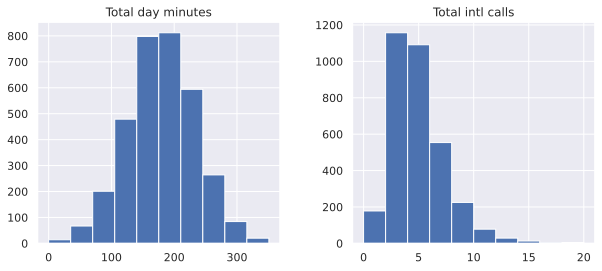

In [17]:
features = ["Total day minutes", "Total intl calls"]
df[features].hist(figsize=(10, 4));

Что видим:
- *Total day minutes* — похоже на нормальное (гауссово) распределение: симметричный колокол.
- *Total intl calls* — скошено вправо: большинство клиентов делают мало международных звонков, но есть хвост с высокими значениями.

Форма распределения важна: многие ML-алгоритмы неявно предполагают нормальность (линейная регрессия, LDA). Сильно скошенные признаки иногда стоит логарифмировать.

#### Оценка плотности (KDE)

Другой способ посмотреть на то же самое — *kernel density estimate* (KDE), сглаженная версия гистограммы. Её главное преимущество: результат не зависит от выбора ширины бинов.

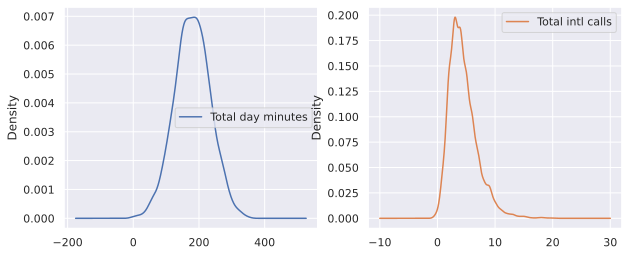

In [6]:
df[features].plot(
    kind="density", subplots=True, layout=(1, 2), sharex=False, figsize=(10, 4)
);

Seaborn умеет строить гистограмму и KDE вместе — удобно сравнивать:

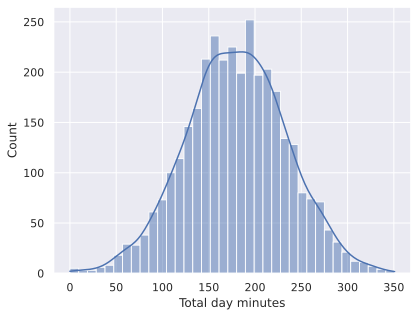

In [15]:
sns.histplot(df["Total day minutes"], kde=True);

#### Box plot (ящик с усами)

Box plot — ещё один взгляд на то же распределение, но делает акцент на статистиках: медиане, квартилях и выбросах.

Как читать box plot:

```
    |----[=====|=====]-----|  o   o
         Q1   med  Q3         outliers
```

- **Ящик**: от $Q_1$ (25-й перцентиль) до $Q_3$ (75-й перцентиль) — здесь лежит середина данных
- **Линия внутри**: медиана ($Q_2$, 50-й перцентиль)
- **Усы**: от $Q_1 - 1.5 \cdot IQR$ до $Q_3 + 1.5 \cdot IQR$, где $IQR = Q_3 - Q_1$
- **Точки за усами**: выбросы (outliers)

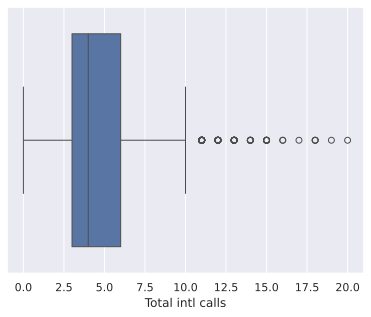

In [8]:
sns.boxplot(x="Total intl calls", data=df);

Видно, что большое количество международных звонков встречается редко — это выбросы правее правого уса.

Числовые статистики можно получить через `describe()`:

In [9]:
df[features].describe()

,Total day minutes,Total intl calls
count,3333.000000,3333.000000
mean,179.775098,4.479448
std,54.467389,2.461214
min,0.000000,0.000000
25%,143.700000,3.000000
50%,179.400000,4.000000
75%,216.400000,6.000000
max,350.800000,20.000000


#### Violin plot

Violin plot — гибрид box plot и KDE: показывает и форму распределения, и квартили одновременно.

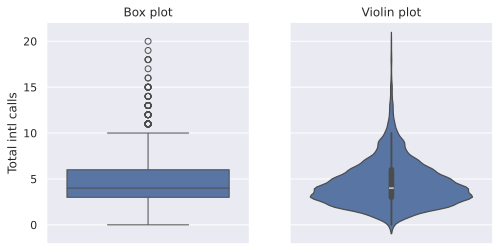

In [10]:
_, axes = plt.subplots(1, 2, sharey=True, figsize=(8, 4))
sns.boxplot(data=df["Total intl calls"], ax=axes[0])
axes[0].set_title("Box plot")
sns.violinplot(data=df["Total intl calls"], ax=axes[1])
axes[1].set_title("Violin plot");

В данном случае violin plot не добавляет много нового — и так видно, что распределение скошено вправо. Но на других данных он может быть информативнее box plot, особенно когда распределение мультимодальное (несколько «горбов»).

**Задание преподавателю на занятии:** постройте box plot и гистограмму для признака `Account length`. Как выглядит распределение?

In [ ]:
# Ваш код здесь


### 2.2 Категориальные и бинарные признаки

*Категориальные* признаки принимают конечный набор значений, каждое из которых обозначает некоторую группу. *Бинарные* — частный случай: ровно два значения (Yes/No, 0/1). *Порядковые* (ordinal) — категориальные со смыслом порядка (1-й класс, 2-й класс, ...).

#### Таблица частот

Посмотрим на распределение целевой переменной:

In [11]:
df["Churn"].value_counts()

Churn
0    2850
1     483
Name: count, dtype: int64

Данные **несбалансированы**: лояльных клиентов ~86%, ушедших ~14%. Это типичная ситуация в задачах оттока. Если просто предсказывать «никто не уйдёт», получим 86% точности — но модель будет бесполезной. Нужно будет учитывать это при оценке качества.

#### Bar plot (столбчатая диаграмма)

Столбчатая диаграмма — это, по сути, визуальная версия таблицы частот.

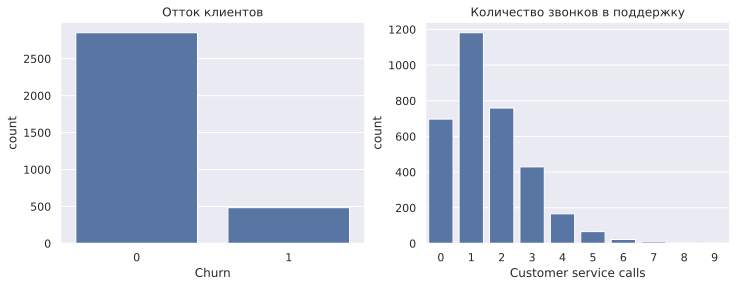

In [12]:
_, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x="Churn", data=df, ax=axes[0])
axes[0].set_title("Отток клиентов")

sns.countplot(x="Customer service calls", data=df, ax=axes[1])
axes[1].set_title("Количество звонков в поддержку");

Несколько важных отличий bar plot от гистограммы:
1. **Гистограмма** — для числовых переменных, **bar plot** — для категориальных.
2. Ось X у гистограммы — числовая шкала; у bar plot — список категорий (порядок можно менять).
3. У гистограммы ширина бина имеет смысл; у bar plot столбцы — просто метки.

График с `Customer service calls` намекает: большинство клиентов решают вопрос за 1–3 звонка. Но нас интересует хвост — там может скрываться большая доля оттока. Это гипотеза — проверим её позже.

**Задание преподавателю на занятии:** постройте bar plot для `International plan`. Сколько клиентов подключили международный план?

In [ ]:
# Ваш код здесь


---
## 3. Многомерный анализ

*Многомерный* анализ (multivariate) — ищем **взаимосвязи** между признаками. Именно здесь начинается настоящий разведочный анализ данных для ML: какие признаки связаны с целевой переменной? Есть ли мультиколлинеарность?

### 3.1 Количественный vs. Количественный

#### Корреляционная матрица

Корреляция Пирсона показывает линейную связь между двумя числовыми переменными: от −1 (обратная) до +1 (прямая), 0 — нет линейной связи.

Некоторые ML-алгоритмы (например, линейная регрессия) плохо работают, когда признаки сильно коррелируют между собой — это называется **мультиколлинеарностью**. Heatmap корреляционной матрицы — быстрый способ это обнаружить.

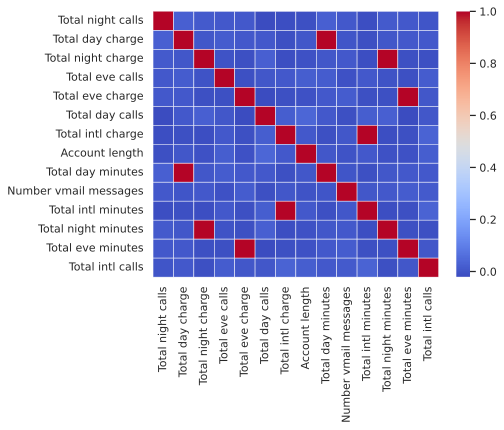

In [13]:
# Отберём только числовые столбцы, уберём категориальные по смыслу
numerical = list(
    set(df.columns)
    - {"State", "International plan", "Voice mail plan", "Area code", "Churn", "Customer service calls"}
)

corr_matrix = df[numerical].corr()
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", linewidths=0.5);

Хорошо видно несколько ярко-красных блоков. Это признаки вроде `Total day charge` и `Total day minutes` — цена напрямую вычисляется из минут, поэтому корреляция = 1. Такие признаки называют **зависимыми** или **производными** — они не несут новой информации.

Уберём их:

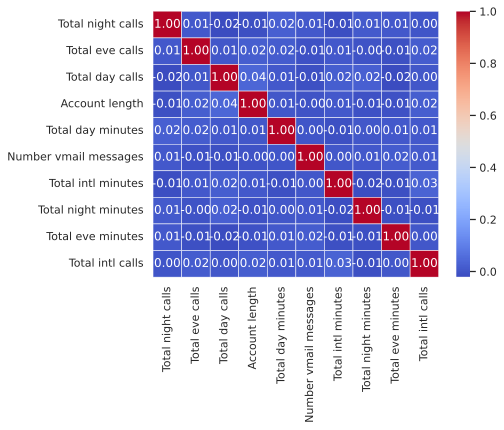

In [14]:
numerical = list(
    set(numerical)
    - {"Total day charge", "Total eve charge", "Total night charge", "Total intl charge"}
)

corr_matrix = df[numerical].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5);

Теперь сильных корреляций нет — это хорошо. Оставшиеся признаки относительно независимы.

#### Диаграмма рассеяния (Scatter plot)

Scatter plot показывает пары значений двух числовых переменных как точки на плоскости.

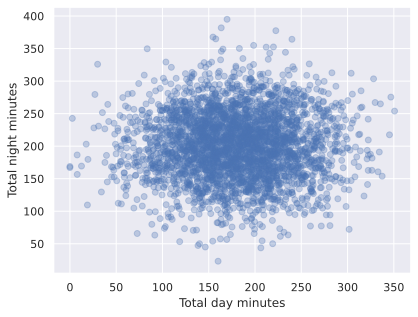

In [15]:
plt.scatter(df["Total day minutes"], df["Total night minutes"], alpha=0.3)
plt.xlabel("Total day minutes")
plt.ylabel("Total night minutes");

«Эллипсообразное» облако точек, ориентированное вдоль осей — признак отсутствия корреляции. Если бы признаки коррелировали, облако было бы вытянуто по диагонали.

Seaborn добавляет гистограммы по краям — сразу видно и совместное, и маргинальные распределения:

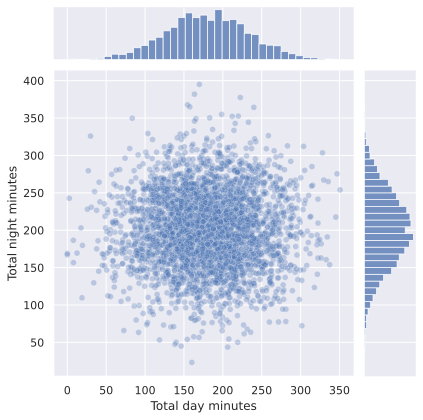

In [16]:
sns.jointplot(x="Total day minutes", y="Total night minutes", data=df, kind="scatter", alpha=0.3);

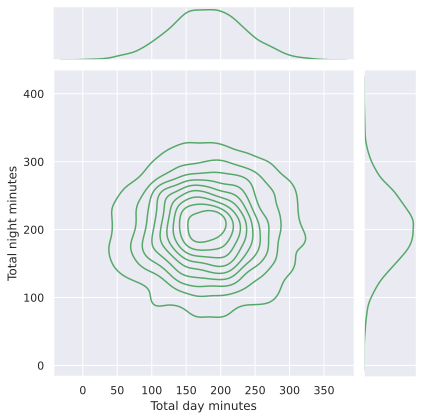

In [17]:
# KDE-версия того же графика — сглаженная «тепловая карта» совместного распределения
sns.jointplot(x="Total day minutes", y="Total night minutes", data=df, kind="kde", color="g");

#### Матрица диаграмм рассеяния (Pairplot)

Когда признаков несколько, удобно посмотреть на все пары сразу. По диагонали — распределение каждого признака, вне диагонали — scatter plots для каждой пары.

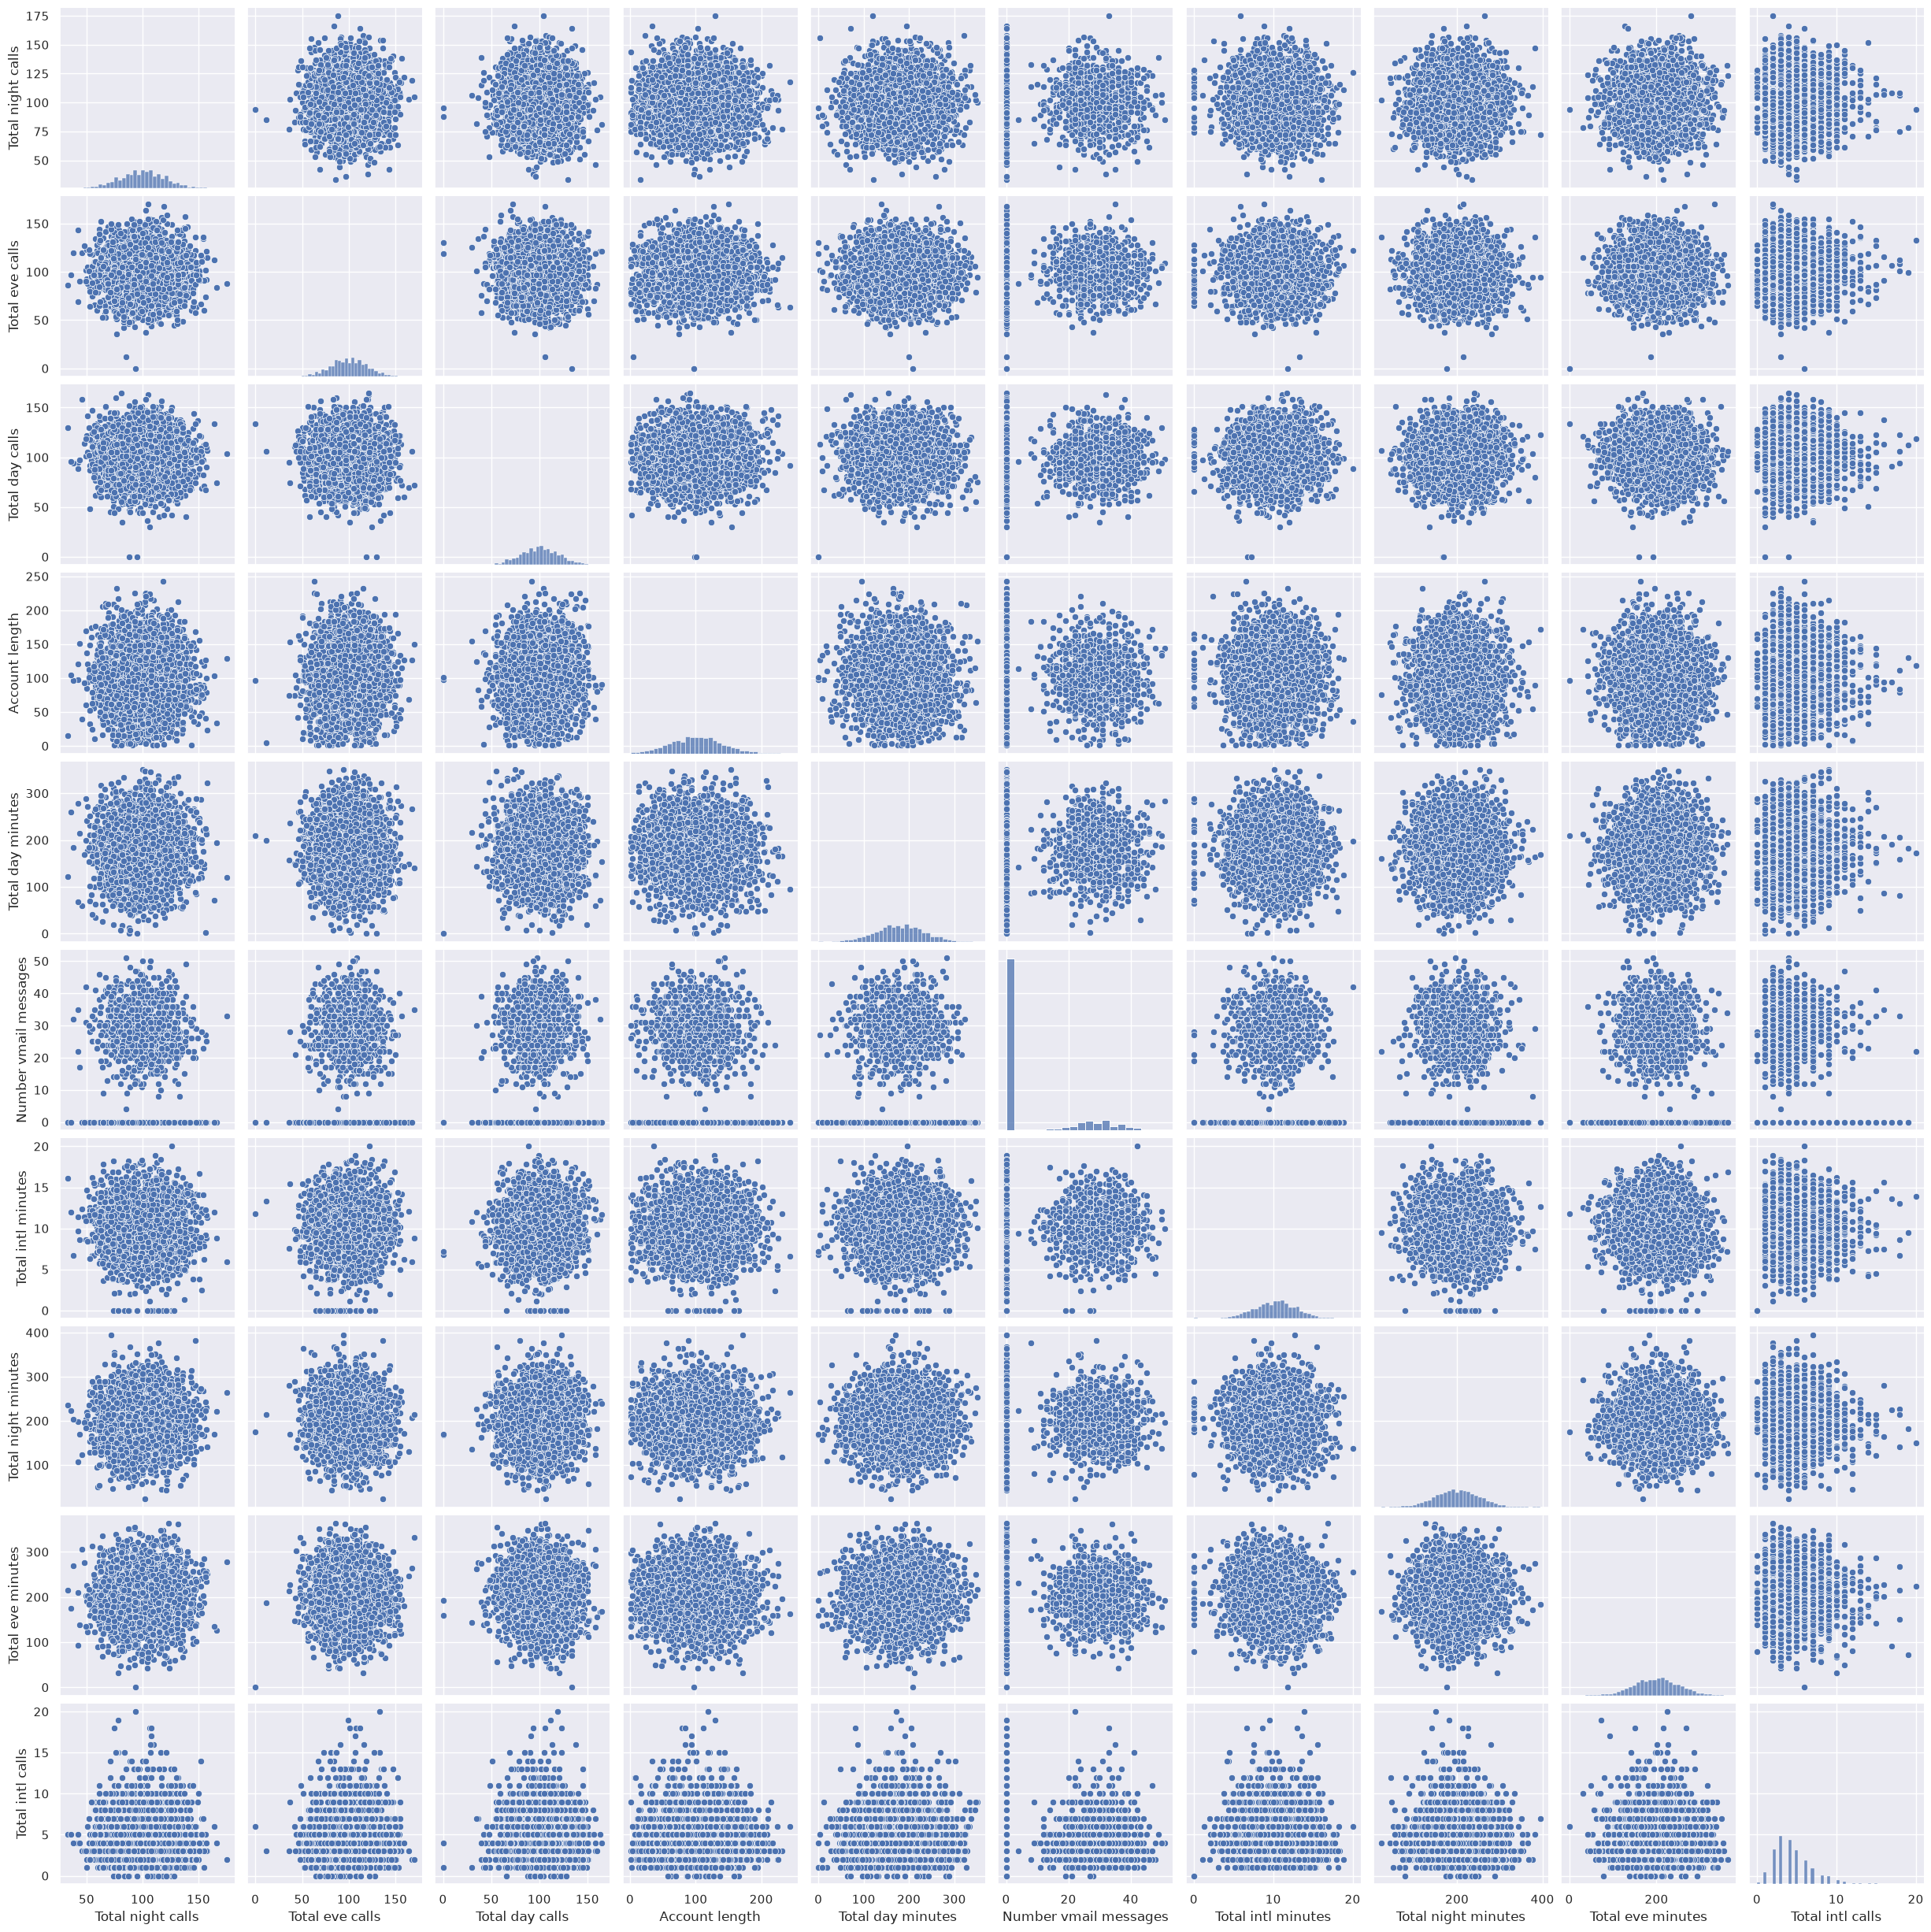

In [18]:
# PNG быстрее рендерится для сложных графиков
%config InlineBackend.figure_format = 'png'
sns.pairplot(df[numerical]);

In [19]:
%config InlineBackend.figure_format = 'svg'

На таком графике сразу видны структурные закономерности: нормальные распределения на диагонали, отсутствие выраженных паттернов на scatter plots — всё говорит о том, что признаки относительно независимы.

**Задание преподавателю на занятии:** выберите два признака, которые по вашей интуиции должны быть независимы, и два, которые могут быть связаны. Постройте для них scatter plots.

In [ ]:
# Ваш код здесь


### 3.2 Количественный vs. Категориальный

Это сердце разведочного анализа для задач классификации: **как числовые признаки ведут себя в разных классах?**

Раскрасим scatter plot по значению `Churn`:

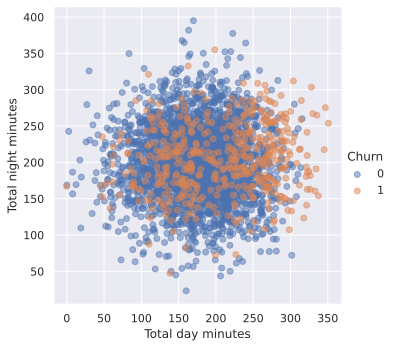

In [20]:
sns.lmplot(
    x="Total day minutes", y="Total night minutes",
    data=df, hue="Churn", fit_reg=False, scatter_kws={"alpha": 0.5}
);

Точки для ушедших клиентов немного тяготеют к правому верхнему углу — такие клиенты чаще звонят и днём, и ночью. Но граница нечёткая, на основе только этих двух признаков разделить классы сложно.

#### Box plots по всем признакам

Очень эффективный приём — построить box plot каждого признака, разбитый по целевой переменной. Сразу видно, какие признаки «различают» классы:

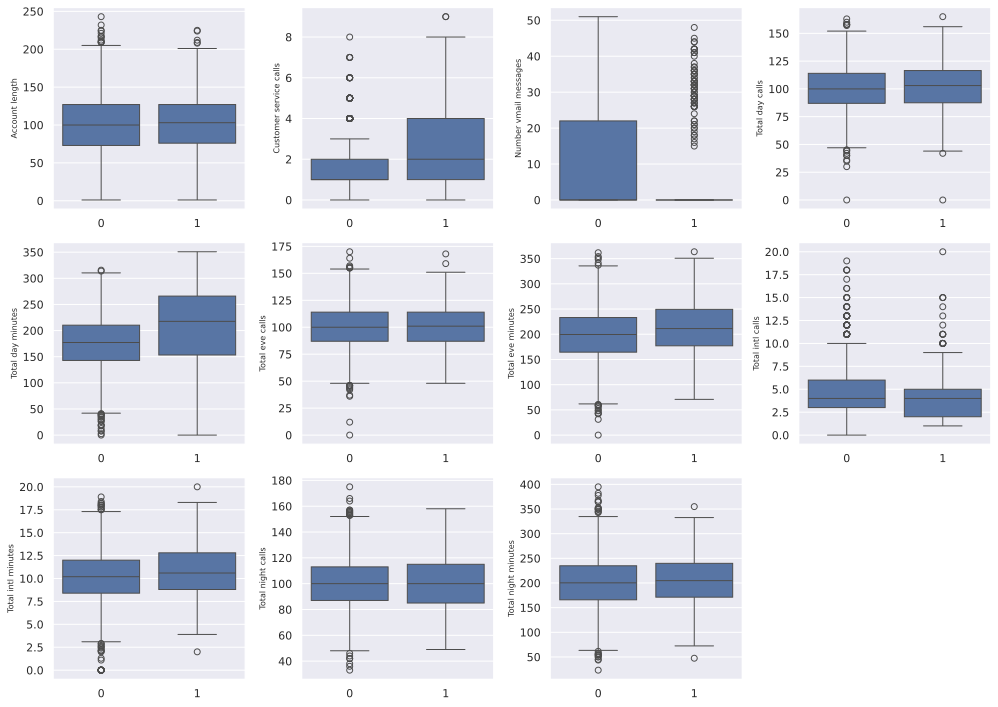

In [21]:
# Добавим Customer service calls — он порядковый, но можно анализировать как числовой
numerical_with_cs = numerical + ["Customer service calls"]

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(14, 10))

for idx, feat in enumerate(sorted(numerical_with_cs)):
    ax = axes[idx // 4, idx % 4]
    sns.boxplot(x="Churn", y=feat, data=df, ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel(feat, fontsize=8)

# Убираем лишние пустые оси
for idx in range(len(numerical_with_cs), 12):
    axes[idx // 4, idx % 4].set_visible(False)

fig.tight_layout();

Уже на этом графике можно сделать важные выводы. Наибольшее расхождение между ушедшими и оставшимися клиентами заметно у трёх признаков: **Total day minutes**, **Customer service calls** и **Number vmail messages**. Именно они, скорее всего, окажутся важными в модели — и позже, когда будем строить деревья решений, убедимся в этом.

Рассмотрим `Total day minutes` подробнее:

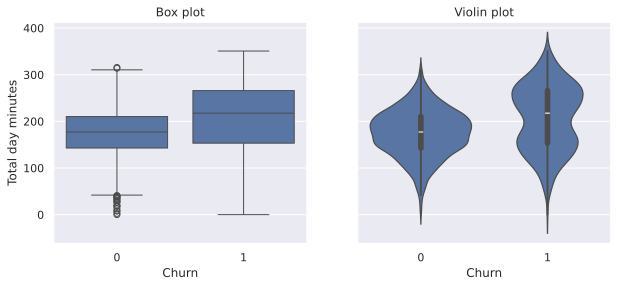

In [22]:
_, axes = plt.subplots(1, 2, sharey=True, figsize=(10, 4))

sns.boxplot(x="Churn", y="Total day minutes", data=df, ax=axes[0])
axes[0].set_title("Box plot")

sns.violinplot(x="Churn", y="Total day minutes", data=df, ax=axes[1])
axes[1].set_title("Violin plot");

**Интересное наблюдение:** клиенты, которые ушли, в среднем говорят по телефону *больше*. Возможная гипотеза: они недовольны тарифом — при высоком потреблении он невыгоден. Компании стоит рассмотреть скидки для активных пользователей. Конечно, это требует дополнительного экономического анализа.

#### catplot — количественный признак в разрезе двух категориальных

Иногда нужно посмотреть сразу на два среза: например, как `Total day minutes` зависит от `Churn` при разном количестве звонков в поддержку.

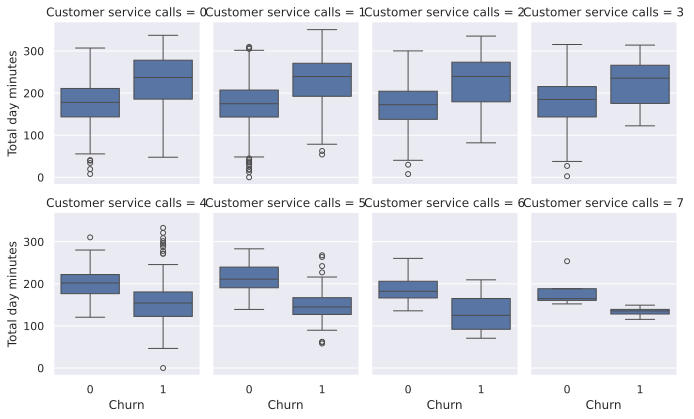

In [23]:
sns.catplot(
    x="Churn",
    y="Total day minutes",
    col="Customer service calls",
    data=df[df["Customer service calls"] < 8],
    kind="box",
    col_wrap=4,
    height=3,
    aspect=0.8,
);

При 1–3 звонках в поддержку ушедшие клиенты действительно говорят больше. Но начиная с 4 звонков это различие исчезает — там количество минут перестаёт быть главным фактором. По всей видимости, при многих жалобах клиент уходит вне зависимости от объёма использования.

**Задание преподавателю на занятии:** постройте box plot для `Customer service calls` по группам `Churn`. Что можно сказать?

In [ ]:
# Ваш код здесь


### 3.3 Категориальный vs. Категориальный

#### Countplot с `hue`

Самый простой способ — добавить цветовое кодирование к bar plot через параметр `hue`:

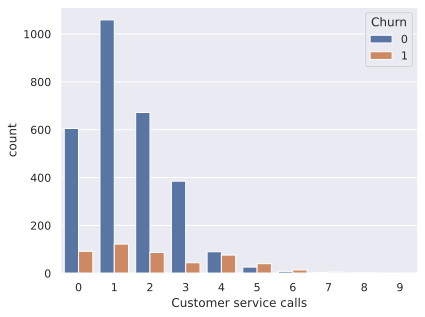

In [24]:
sns.countplot(x="Customer service calls", hue="Churn", data=df);

**Наблюдение:** при 1–3 звонках в поддержку доля ушедших мала. После 4 звонков она резко возрастает. Это очень чёткий сигнал — `Customer service calls` будет сильным признаком.

Посмотрим на бинарные признаки:

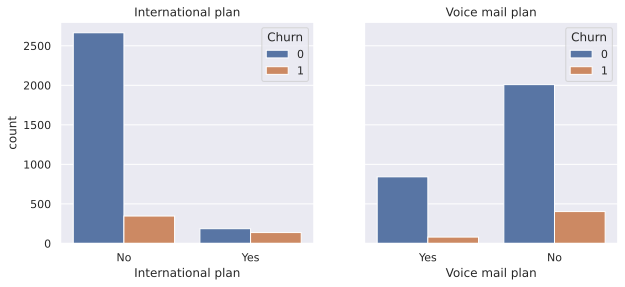

In [25]:
_, axes = plt.subplots(1, 2, sharey=True, figsize=(10, 4))

sns.countplot(x="International plan", hue="Churn", data=df, ax=axes[0])
axes[0].set_title("International plan")

sns.countplot(x="Voice mail plan", hue="Churn", data=df, ax=axes[1])
axes[1].set_title("Voice mail plan");

**Наблюдение:**
- **International plan = Yes**: доля оттока сильно выше (~42% против ~11%). Это мощный признак.
- **Voice mail plan**: похожего эффекта не видно.

#### Таблица сопряжённости (Cross tabulation)

Классический инструмент из статистики — позволяет увидеть распределение одной переменной при каждом значении другой:

In [26]:
pd.crosstab(df["International plan"], df["Churn"])

Churn,0,1
International plan,,
No,2664,346
Yes,186,137


In [27]:
# Нормированная версия — доли по строкам
pd.crosstab(df["International plan"], df["Churn"], normalize="index").round(3)

Churn,0,1
International plan,,
No,0.885,0.115
Yes,0.576,0.424


Теперь в числах: среди клиентов *с* международным планом уходит **42%**, а без него — только **11%**. Такую разницу нельзя игнорировать — это один из самых сильных сигналов в датасете.

Посмотрим, есть ли региональные эффекты:

In [28]:
churn_by_state = (
    df.groupby("State")["Churn"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "churn rate", "count": "N"})
    .sort_values("churn rate", ascending=False)
)
churn_by_state.head(10)

,churn rate,N
State,,
CA,0.264706,34
NJ,0.264706,68
TX,0.250000,72
MD,0.242857,70
SC,0.233333,60
MI,0.219178,73
MS,0.215385,65
WA,0.212121,66
NV,0.212121,66


На первый взгляд, некоторые штаты имеют очень высокий отток (CA, NJ). Но посмотрите на колонку N — там всего 30–70 клиентов. **Малый размер выборки делает выводы ненадёжными**: это может быть случайный шум, а не реальный эффект. Всегда проверяйте, сколько наблюдений стоит за цифрой.

---
## Итог занятия

Сегодня разобрали:

- Одномерный анализ: гистограмма, KDE, box plot, violin plot (количественные), таблица частот, bar plot (категориальные)
- Многомерный анализ: корреляционная матрица, scatter plot, pairplot (количественный vs. количественный)
- Box plot/catplot по классам, `lmplot` с `hue` (количественный vs. категориальный)
- Countplot с `hue`, crosstab, осторожность с малыми выборками по группам (категориальный vs. категориальный)

**Дальше:**
- Практика по этой теме — `lesson02_visual_practice.ipynb` (Titanic)
- Доп. материалы (`DataFrame.plot()`, Plotly, взгляд на весь датасет через понижение размерности) — `lesson02_visual_advanced.ipynb`
- Следующее занятие — первые модели машинного обучения (деревья решений)